In [2]:
# Visual before/after check for src/preprocessing/specular_removal.py
# (same 10 sample images used by tests/preprocessing/test_specular_removal.py)

import os
import sys
import glob

def find_project_root(start):
    path = os.path.abspath(start)
    while True:
        if os.path.exists(os.path.join(path, "requirements.txt")) or os.path.isdir(os.path.join(path, ".git")):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            return os.path.abspath(start)
        path = parent

PROJECT_ROOT = find_project_root(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import cv2
import matplotlib.pyplot as plt

from src.preprocessing.specular_removal import ShenParams, remove_specular_highlights, specular_map

In [3]:
# Same candidate folders/order as tests/preprocessing/test_specular_removal.py,
# so this notebook shows exactly the images the test suite exercises.
SAMPLE_GLOBS = [
    os.path.join(PROJECT_ROOT, "data", "raw", "CarDD_release", "CarDD_release", "CarDD_COCO", "train2017", "*.jpg"),
    #os.path.join(PROJECT_ROOT, "data", "raw", "Car parts coco-segmentation", "train", "*.jpg"),
    #os.path.join(PROJECT_ROOT, "data", "raw", "Car-Parts-Segmentation", "trainingset", "JPEGImages", "*.jpg"),
]

def find_sample_images(n=10):
    for pattern in SAMPLE_GLOBS:
        files = sorted(glob.glob(pattern))
        if len(files) >= n:
            return files[:n]
    return []

sample_images = find_sample_images(10)
print(f"Found {len(sample_images)} sample images")
for p in sample_images:
    print(" -", p)

Found 10 sample images
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\train2017\000001.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\train2017\000002.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\train2017\000003.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\train2017\000004.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\train2017\000005.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\train2017\000006.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\train2017\000007.jpg
 - c:\Users\barucr

In [4]:
def show_before_after(image_paths, params=None, show_specular_map=True):
    cols = 3 if show_specular_map else 2
    fig, axes = plt.subplots(len(image_paths), cols, figsize=(4 * cols, 4 * len(image_paths)))
    if len(image_paths) == 1:
        axes = axes[None, :]

    for row, path in enumerate(image_paths):
        image_bgr = cv2.imread(path)
        diffuse_bgr = remove_specular_highlights(image_bgr, params=params)

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        diffuse_rgb = cv2.cvtColor(diffuse_bgr, cv2.COLOR_BGR2RGB)

        axes[row, 0].imshow(image_rgb)
        axes[row, 0].set_title(f"{os.path.basename(path)} - before", fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(diffuse_rgb)
        axes[row, 1].set_title("after (specular removed)", fontsize=9)
        axes[row, 1].axis('off')

        if show_specular_map:
            removed = specular_map(image_bgr, diffuse_bgr)
            axes[row, 2].imshow(removed, cmap='gray')
            axes[row, 2].set_title("specular magnitude removed", fontsize=9)
            axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()

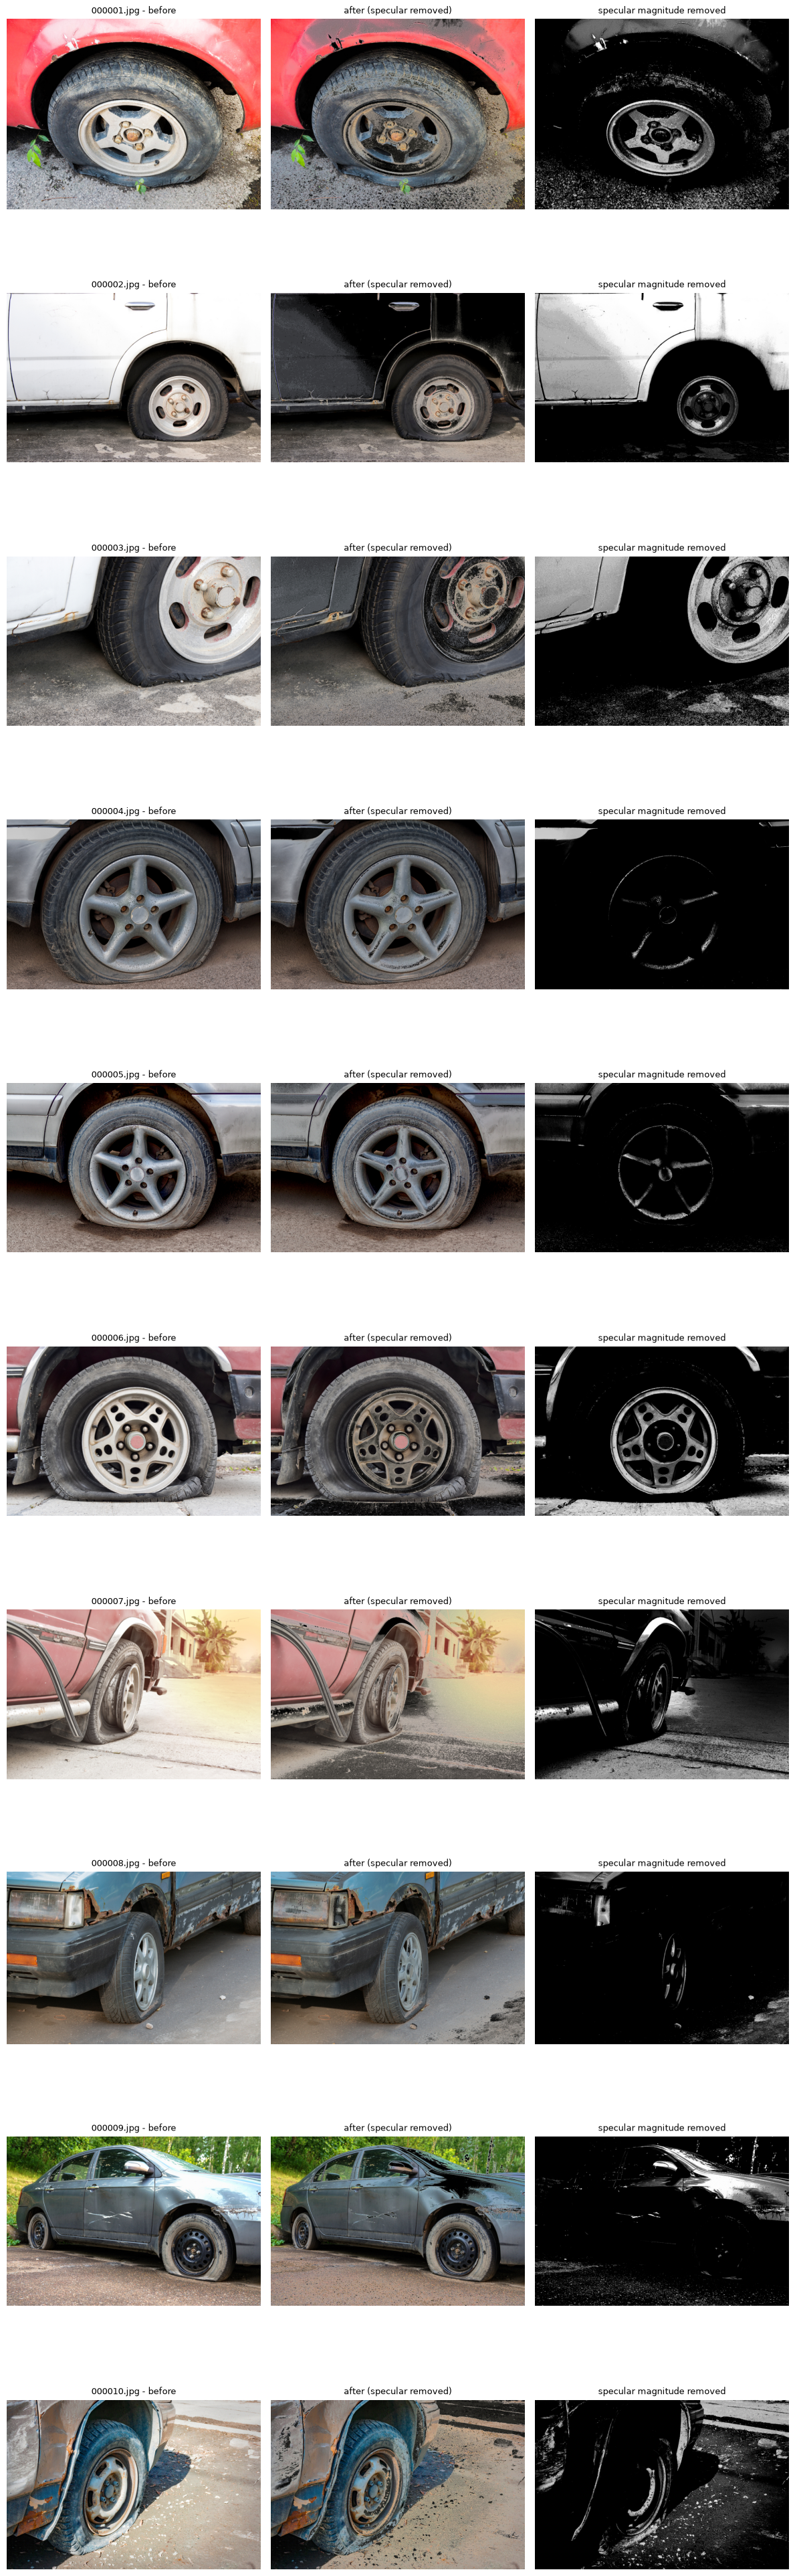

In [5]:
show_before_after(sample_images, params=ShenParams())